In [39]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import seaborn as sb
from model import cnn


In [40]:
model = cnn()
model.parameters

<bound method Module.parameters of cnn(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6272, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=1, bias=True)
)>

In [41]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [42]:
train_data = datasets.ImageFolder(root='./dataset/train',transform=train_transform)
test_data = datasets.ImageFolder(root='./dataset/test',transform=test_transform)
val_data = datasets.ImageFolder(root='./dataset/val',transform=val_transform)

In [43]:
train_batch = DataLoader(
    train_data,
    batch_size=16,
    shuffle=True
)

test_batch = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False
)

val_batch = DataLoader(
    val_data,
    batch_size=16,
    shuffle=False
)


In [44]:
lossfunc = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.0001)

In [45]:
epochs = 10
training_loss = []
validation_loss = []
best_val = float('inf')

for epoch in range(epochs):
    model.train()
    train_epoch_loss = 0
    
    for xtrain,ytrain in train_batch:
        train_pred = model(xtrain)
        train_loss = lossfunc(train_pred,ytrain.unsqueeze(1).float())

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        train_epoch_loss += train_loss.item()
    train_epoch_loss /= len(train_batch)
    training_loss.append(train_epoch_loss)

    model.eval()
    val_epoch_loss = 0
    with torch.no_grad():
        for xval,yval in val_batch:
            val_pred = model(xval)
            val_loss = lossfunc(val_pred,yval.unsqueeze(1).float())

            val_epoch_loss += val_loss.item()
        val_epoch_loss /= len(val_batch)
        validation_loss.append(val_epoch_loss)

        print(f'Epoch:{epoch}, Training Loss:{train_epoch_loss}, Validation Loss:{val_epoch_loss}') 
    
    if val_epoch_loss < best_val:
        best_val = val_epoch_loss
        torch.save(model.state_dict(),'saved_model/best.pth')   
        print('Saved Best Model!')     
          
        

Epoch:0, Training Loss:0.6547836206461254, Validation Loss:0.6637668907642365
Saved Best Model!
Epoch:1, Training Loss:0.5408895007873836, Validation Loss:0.4712998889959775
Saved Best Model!
Epoch:2, Training Loss:0.4169037459712279, Validation Loss:0.41230169855631316
Saved Best Model!
Epoch:3, Training Loss:0.35708584989372055, Validation Loss:0.3442909178825525
Saved Best Model!
Epoch:4, Training Loss:0.31287398738296407, Validation Loss:0.30242684254279506
Saved Best Model!
Epoch:5, Training Loss:0.28473169121303055, Validation Loss:0.28079150044001067
Saved Best Model!
Epoch:6, Training Loss:0.24382566327327176, Validation Loss:0.2872030477111156
Epoch:7, Training Loss:0.21234230108951269, Validation Loss:0.23469684502253166
Saved Best Model!
Epoch:8, Training Loss:0.18123881450217022, Validation Loss:0.21181380863373095
Saved Best Model!
Epoch:9, Training Loss:0.15849278906458303, Validation Loss:0.20065252597515398
Saved Best Model!


Text(0.5, 1.0, 'Training vs Validation Loss')

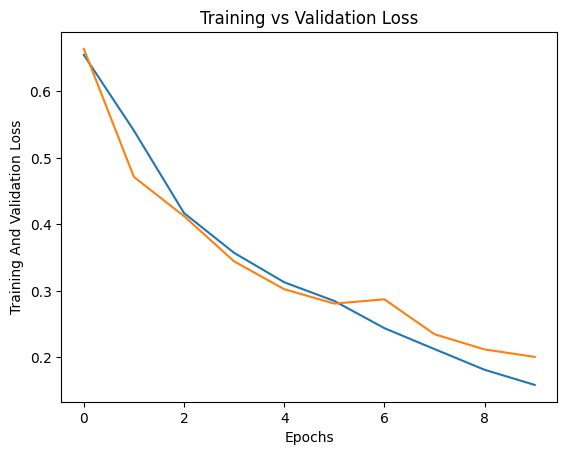

In [46]:
plt.plot(training_loss)
plt.plot(validation_loss)

plt.ylabel('Training And Validation Loss')
plt.xlabel('Epochs')
plt.title('Training vs Validation Loss')
